# Uptake efficiency — comparison of beta estimation methods

4x2 panels, one row per experiment location (Japan, Vancouver Island, Baja California, Ecuador). Left column shows the "true" uptake efficiency (from `roms_marbl_dic`/`roms_marbl_alk`, black) against the efficiency reconstructed by each beta-estimation method (REF, MON, MEAN, CONST, CESM, SODA-mon, SODA-clim), colored consistently across panels. Right column shows the difference (truth minus reconstruction) for each method.

Produces one such figure per scenario (DOR, OAE), both loaded and plotted in this notebook.

In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Configuration

In [2]:
# --- User choice ---
AMPLITUDE = "8"    # one of "10", "7", "8" -> nominal perturbation magnitude 10 / 100 / 1000
SCENARIO_KEYS = ["dor", "oae"]   # scenarios to load and plot

In [3]:
LOCATIONS = {
    "J": {"prefix": "JP", "title": "Japan"},
    "V": {"prefix": "VI", "title": "Vancouver Island"},
    "B": {"prefix": "BC", "title": "Baja California"},
    "E": {"prefix": "EC", "title": "Ecuador"},
}

AMP_LABELS = {"10": "10", "7": "100", "8": "1000"}

METHODS = {
    "REF":       {"exp": "exp0", "color": "#e41a1c"},
    "MON":       {"exp": "exp1", "color": "#377eb8"},
    "MEAN":      {"exp": "exp2", "color": "#4daf4a"},
    "CONST":     {"exp": "exp6", "color": "#984ea3"},
    "CESM":      {"exp": "exp3", "color": "#ff7f00"},
    "SODA-mon":  {"exp": "exp8", "color": "#a65628"},
    "SODA-clim": {"exp": "exp9", "color": "#f781bf"},
}

SCENARIOS = {
    "dor": {"base_dir": "roms_marbl_dic", "output_subdir": "OUTPUT_dor", "title": "DOR", "symbol": "⊖"},
    "oae": {"base_dir": "roms_marbl_alk", "output_subdir": "OUTPUT_oae", "title": "OAE", "symbol": "⊕"},
}

## Load data

In [4]:
kwargs = {"combine": "nested", "concat_dim": "time"}

# "Truth": ROMS-MARBL with explicit CDR tracer, one dataset per (scenario, location) at the chosen amplitude.
# Skipped gracefully (with a message) if a location isn't available for a given scenario.
truth = {}
for scenario_key in SCENARIO_KEYS:
    base_dir = SCENARIOS[scenario_key]["base_dir"]
    truth[scenario_key] = {}
    for loc_key, loc in LOCATIONS.items():
        exp = f"{loc['prefix']}{AMPLITUDE}"
        exp_dir = f"exp{exp}"
        try:
            ds_2000 = xr.open_mfdataset(f"{base_dir}/{exp_dir}/OUTPUT/INTEGRATED/integrated.2000*.nc", **kwargs)
            ds_2001 = xr.open_mfdataset(f"{base_dir}/{exp_dir}/OUTPUT/INTEGRATED/integrated.2001*.nc", **kwargs)
        except OSError:
            print(f"  [skip] {scenario_key} {loc_key}: no truth data found for {exp_dir}")
            continue
        ds = xr.concat([ds_2000, ds_2001], dim="time")
        if "abs_time" in ds:
            ds = ds.swap_dims({"time": "abs_time"}).rename({"abs_time": "time"})
        truth[scenario_key][loc_key] = ds

In [5]:
# deficit-tracer estimate under each beta-estimation method (all locations bundled per method), per scenario.
# Skipped gracefully (with a message) if a method isn't available for a given scenario.
methods_ds = {}
for scenario_key in SCENARIO_KEYS:
    output_subdir = SCENARIOS[scenario_key]["output_subdir"]
    methods_ds[scenario_key] = {}
    for method_key, method in METHODS.items():
        try:
            ds = xr.open_mfdataset(
                f"roms/{method['exp']}/{output_subdir}/INTEGRATED/integrated.*.nc", **kwargs
            )
        except OSError:
            print(f"  [skip] {scenario_key} {method_key}: no data found for {method['exp']}")
            continue
        if "abs_time" in ds:
            ds = ds.rename({"abs_time": "time"})
        methods_ds[scenario_key][method_key] = ds

/tmp/ipykernel_1854799/1985632376.py:16: UserWarning: rename 'abs_time' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({"abs_time": "time"})
/tmp/ipykernel_1854799/1985632376.py:16: UserWarning: rename 'abs_time' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({"abs_time": "time"})
/tmp/ipykernel_1854799/1985632376.py:16: UserWarning: rename 'abs_time' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({"abs_time": "time"})
/tmp/ipykernel_1854799/1985632376.py:16: UserWarning: rename 'abs_time' to 'time' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds = ds.rename({"abs_time": "time"})
/tmp/ipykernel_1

## Efficiency computation

In [6]:
def eta_truth(ds, scenario_key):
    ratio = ds["deltaDIC"] / ds["c_conserved"].where(ds["c_conserved"] != 0)
    return 1 - ratio if scenario_key == "dor" else ratio


def eta_method(ds, exp, scenario_key):
    conserved = ds[f"{exp}_conserved"].where(ds[f"{exp}_conserved"] != 0)
    if scenario_key == "dor":
        return 1 - ds[f"{exp}_deficit"] / conserved
    else:
        eff = ds[f"{exp}_oae_def"] / conserved
        if eff.isel(time=-1) < 0: # some of the runs were run with negative forcing
            eff = -eff
        
        return eff

## Plotting

In [7]:
def panel_label(scenario_key, loc_key):
    return f"{loc_key}{AMP_LABELS[AMPLITUDE]}{SCENARIOS[scenario_key]['symbol']}"


def plot_location(ax, scenario_key, loc_key):
    loc = LOCATIONS[loc_key]
    exp = f"{loc['prefix']}{AMPLITUDE}"
    label = panel_label(scenario_key, loc_key)

    ds_truth = truth[scenario_key].get(loc_key)
    if ds_truth is None:
        ax.set_title(f"{label} (no data)")
        return
    ax.plot(ds_truth.time, eta_truth(ds_truth, scenario_key), color="black", linewidth=4, linestyle="dashed", label=rf"Truth ($\mathcal{{E}}$)")

    for method_key, method in METHODS.items():
        ds = methods_ds[scenario_key].get(method_key)
        if ds is None or f"{exp}_conserved" not in ds:
            continue
        ax.plot(ds.time, eta_method(ds, exp, scenario_key), color=method["color"], linewidth=2, label=rf"{method_key} ($\tilde\mathcal{{E}}$)")

    ax.set_title(rf"{label}: $(\mathcal{{E}}$ vs. $\tilde{{\mathcal{{E}}}})$")
    ax.grid()


def plot_location_diff(ax, scenario_key, loc_key, relative=False):
    loc = LOCATIONS[loc_key]
    exp = f"{loc['prefix']}{AMPLITUDE}"
    label = panel_label(scenario_key, loc_key)

    ds_truth = truth[scenario_key].get(loc_key)
    if ds_truth is None:
        ax.set_title(f"{label} (no data)")
        return
    truth_eta = eta_truth(ds_truth, scenario_key)

    for method_key, method in METHODS.items():
        ds = methods_ds[scenario_key].get(method_key)
        if ds is None or f"{exp}_conserved" not in ds:
            continue
        diff =  eta_method(ds, exp, scenario_key) - truth_eta
        if relative:
            diff = 100 * diff / truth_eta.where(truth_eta != 0)
        ax.plot(ds_truth.time, diff, color=method["color"], linewidth=2, label=rf"{method_key} ($\tilde\mathcal{{E}}$)")

    ax.axhline(0, color="black", linewidth=1.5, linestyle="dashed")
    if relative:
        ax.set_title(rf"{label}: $(\tilde{{\mathcal{{E}}}}-\mathcal{{E}})/\mathcal{{E}}$ $\times$ 100")
    else:
        ax.set_title(rf"{label}: $\tilde{{\mathcal{{E}}}}-\mathcal{{E}}$")
    ax.grid()

In [8]:
def make_figure(scenario_key, relative=False, panel_labels="abcdefghijklmnop"):
    fig, axs = plt.subplots(4, 2, figsize=(10, 13), sharex=True)

    loc_order = ["J", "V", "B", "E"]
    for row, loc_key in enumerate(loc_order):
        plot_location(axs[row, 0], scenario_key, loc_key)
        plot_location_diff(axs[row, 1], scenario_key, loc_key, relative=relative)

    # prepend (a), (b), ... to each panel title in row-major order
    if panel_labels:
        for label, ax in zip(panel_labels, axs.flat):
            ax.set_title(f"({label}) {ax.get_title()}")

    xticks = pd.date_range("2000-01-01", periods=5, freq="6MS")
    for ax in axs.flat:
        ax.set_xticks(xticks)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    for ax in axs[-1, :]:
        ax.set_xlabel("Time")

    if relative:
        for ax in axs[:, 1]:
            ax.set_ylabel("%")
        
    # collect handles/labels across all panels, since a missing dataset can leave
    # the top-left panel without the full set of methods
    handles_by_label = {}
    for ax in axs.flat:
        for handle, label in zip(*ax.get_legend_handles_labels()):
            handles_by_label.setdefault(label, handle)
    fig.legend(
        handles_by_label.values(), handles_by_label.keys(),
        loc="lower center", ncol=len(handles_by_label)//2,
        bbox_to_anchor=(0.5, -0.04), handlelength=3
    )

    plt.tight_layout(rect=[0, 0.02, 1, 1])
    return fig

### DOR, absolute error

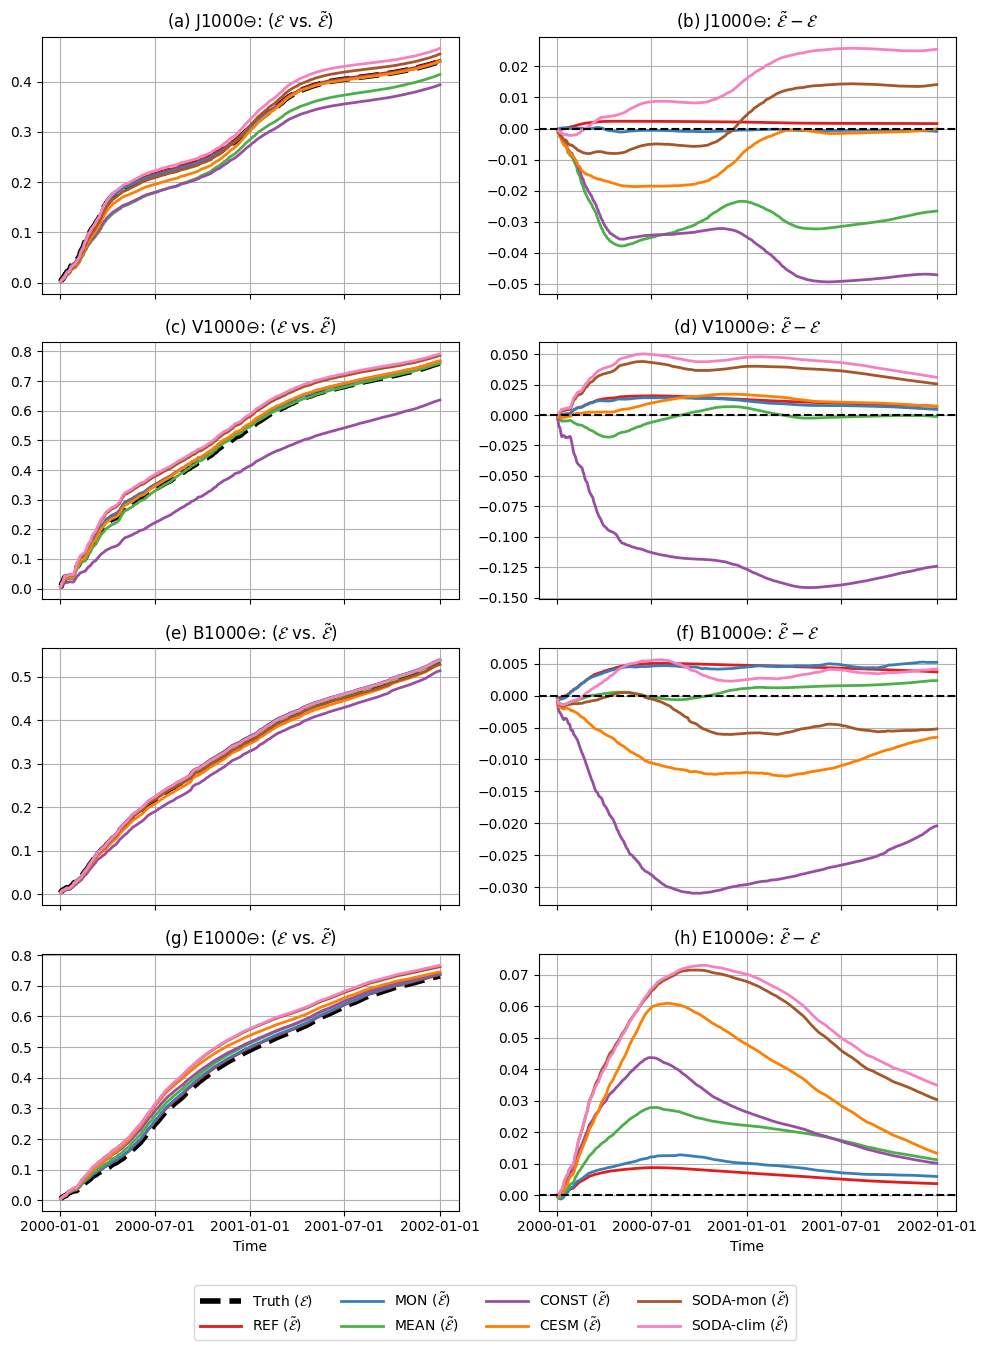

In [11]:
scenario_key = "dor"
fig = make_figure(scenario_key)

In [12]:
fig.savefig(
    f"figures/curves_approx_beta_eta_{scenario_key}_{AMPLITUDE}.png",
    dpi=300,
    bbox_inches="tight",
)

### OAE, absolute error

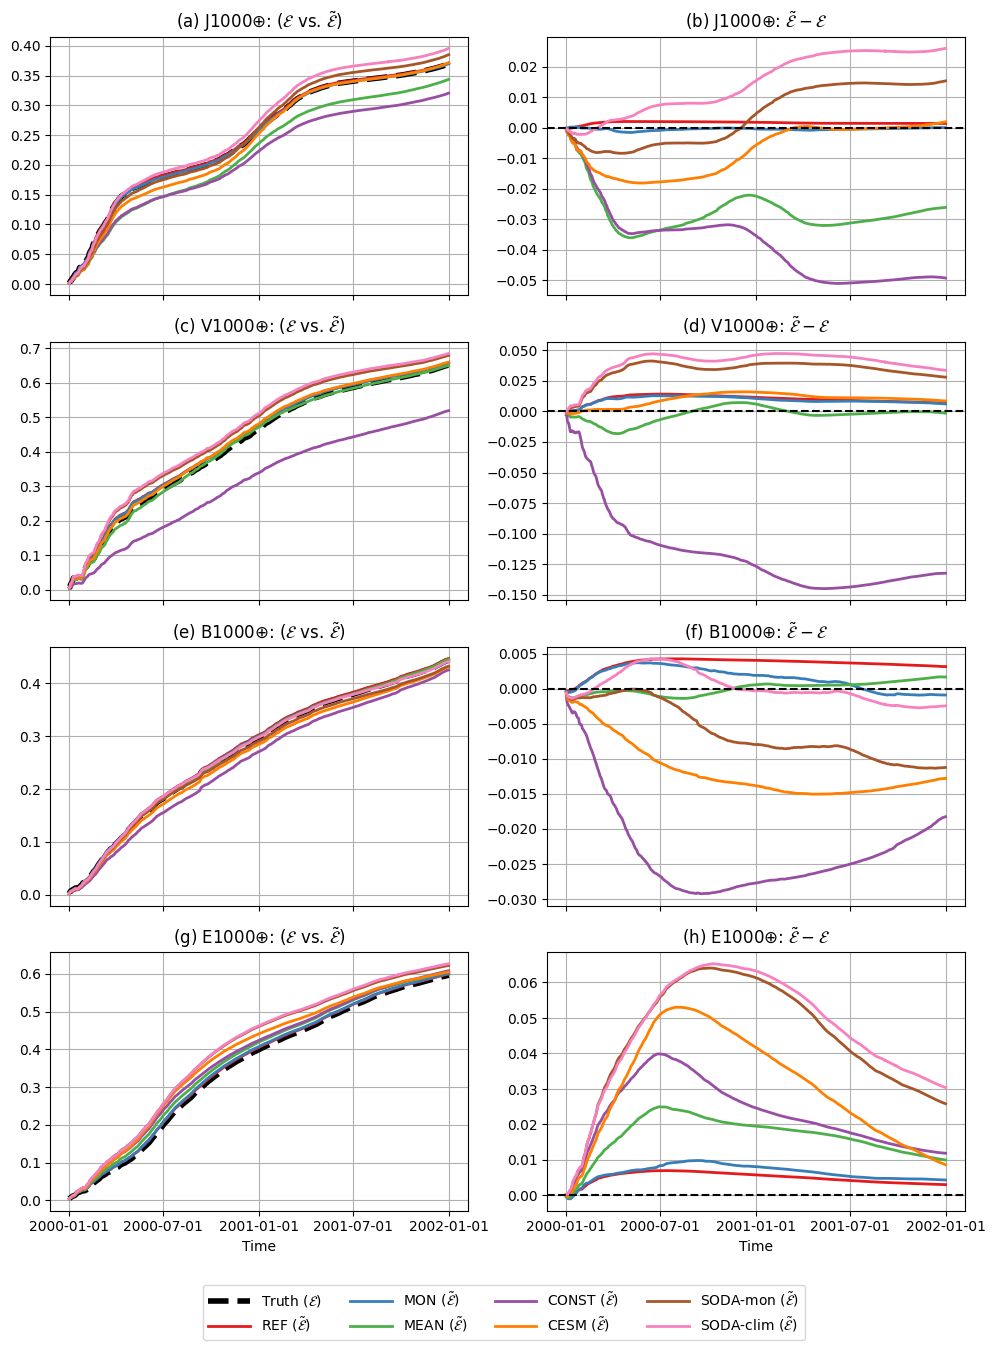

In [9]:
scenario_key = "oae"
fig = make_figure(scenario_key)

In [10]:
fig.savefig(
    f"figures/curves_approx_beta_eta_{scenario_key}_{AMPLITUDE}.png",
    dpi=300,
    bbox_inches="tight",
)

### DOR, relative error

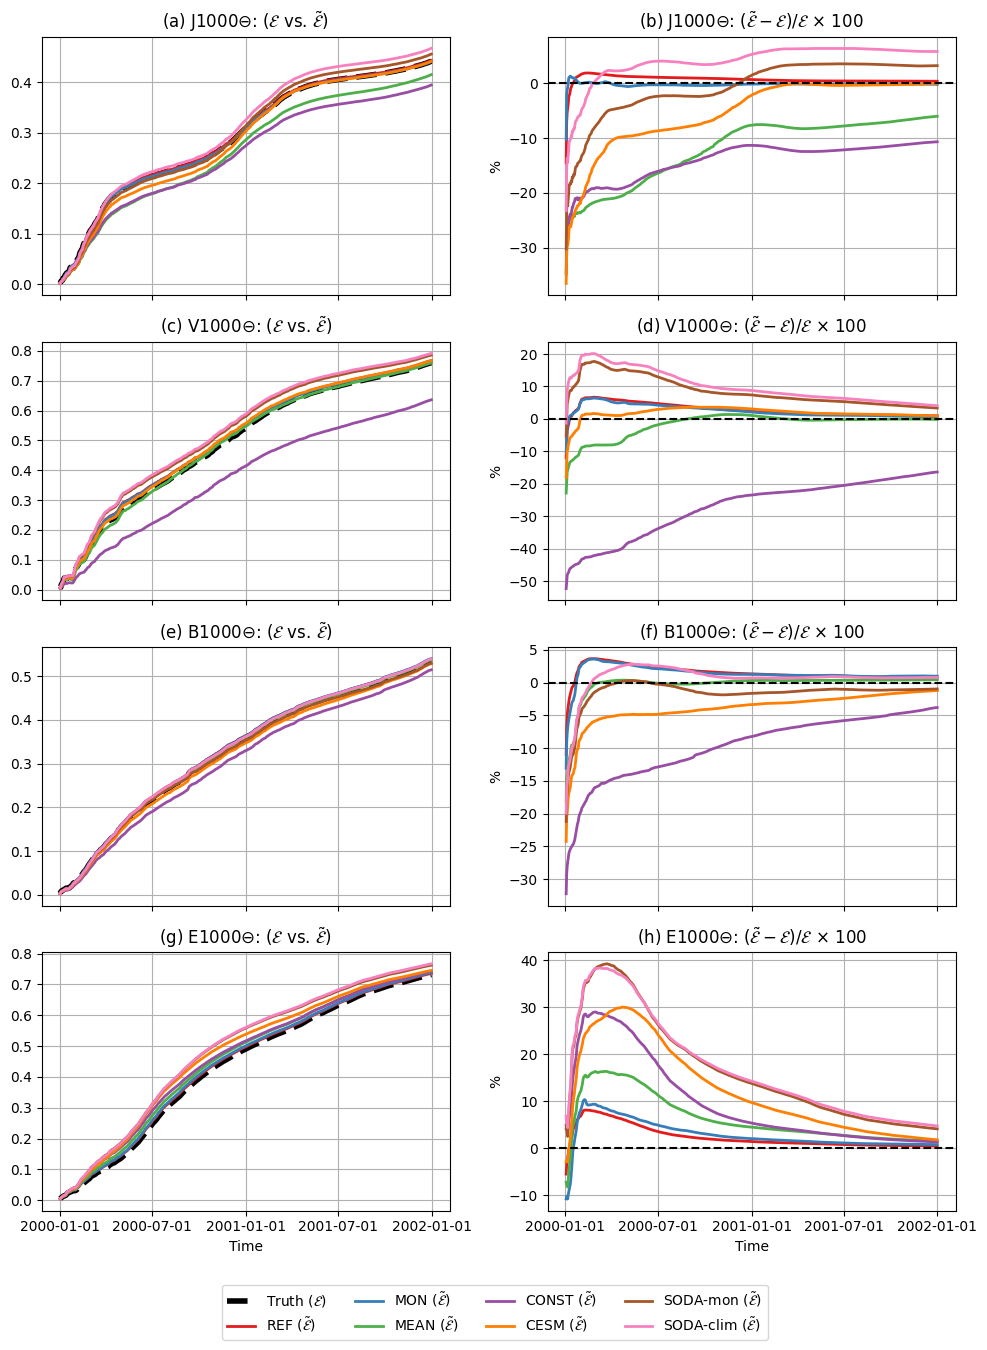

In [13]:
scenario_key = "dor"
fig = make_figure(scenario_key, relative=True)

In [14]:
fig.savefig(
    f"figures/curves_approx_beta_eta_{scenario_key}_{AMPLITUDE}_relative_error.png",
    dpi=300,
    bbox_inches="tight",
)

### OAE, relative error

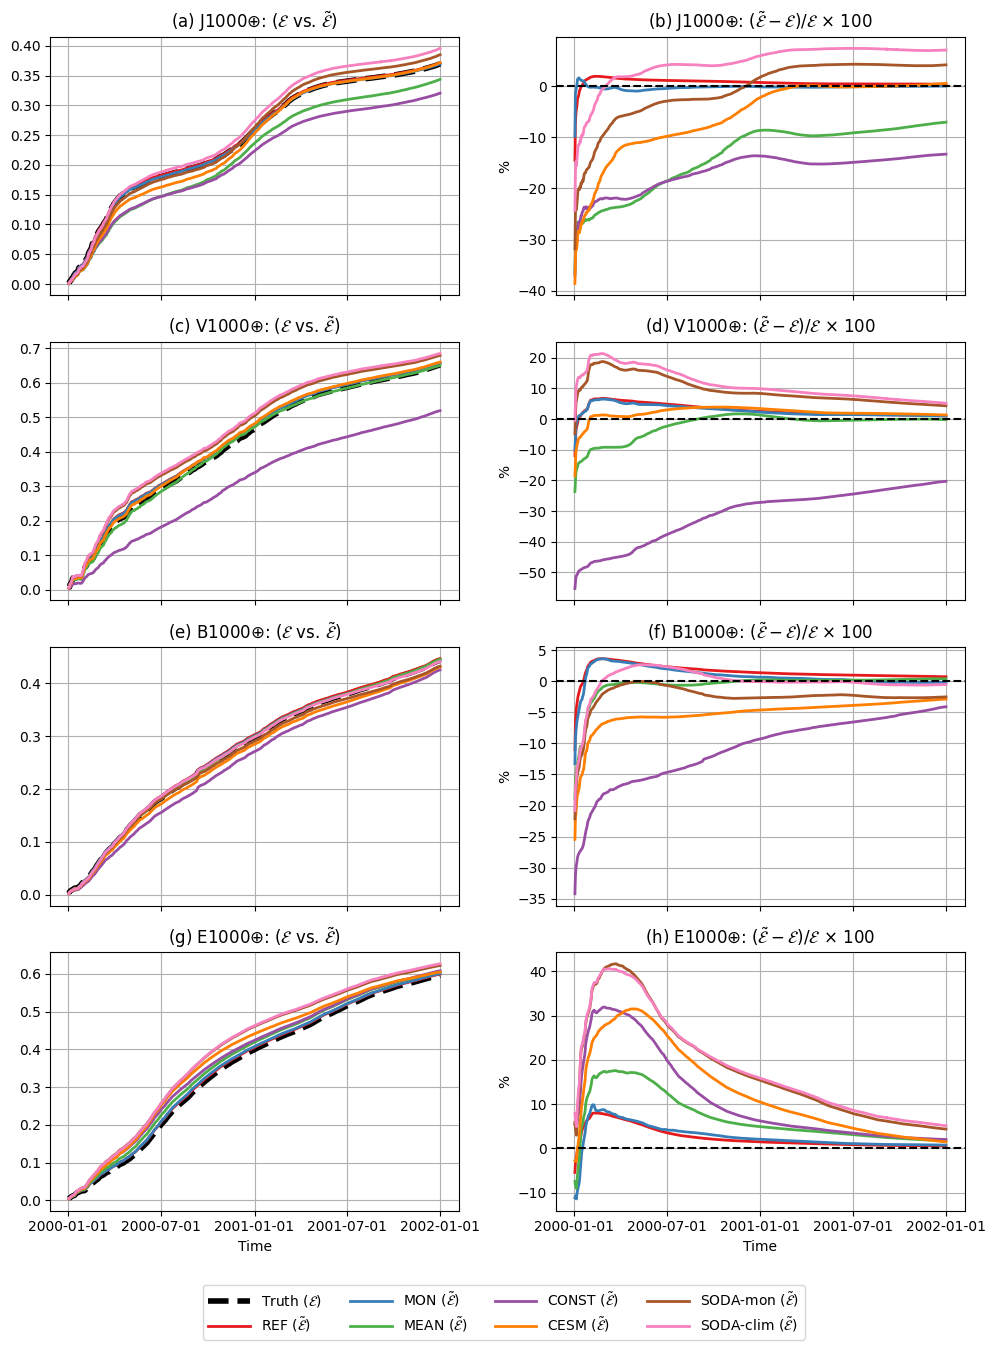

In [11]:
scenario_key = "oae"
fig = make_figure(scenario_key, relative=True)

In [12]:
fig.savefig(
    f"figures/curves_approx_beta_eta_{scenario_key}_{AMPLITUDE}_relative_error.png",
    dpi=300,
    bbox_inches="tight",
)

## Error extremes

Min / max over time of the truth-minus-reconstruction error for every
(location, method) pair, for both the absolute error $\mathcal{E}-\tilde{\mathcal{E}}$
and the relative error $(\mathcal{E}-\tilde{\mathcal{E}})/\mathcal{E}\times100$ (%).
Same quantities that are plotted in the right column above.

In [13]:
def error_extremes(scenario_key, relative=False):
    """min/max over time of (reconstruction - truth) for each (location, method).

    relative=False -> absolute error E~ - E
    relative=True  -> relative error (E~ - E) / E * 100  [%]
    """
    rows = []
    for loc_key, loc in LOCATIONS.items():
        exp = f"{loc['prefix']}{AMPLITUDE}"
        ds_truth = truth[scenario_key].get(loc_key)
        if ds_truth is None:
            continue
        truth_eta = eta_truth(ds_truth, scenario_key)
        for method_key in METHODS:
            ds = methods_ds[scenario_key].get(method_key)
            if ds is None or f"{exp}_conserved" not in ds:
                continue
            diff = eta_method(ds, exp, scenario_key) - truth_eta
            if relative:
                diff = 100 * diff / truth_eta.where(truth_eta != 0)
            rows.append({
                "location": loc["title"],
                "method": method_key,
                "min": float(diff.min(skipna=True)),
                "max": float(diff.max(skipna=True)),
            })
    return pd.DataFrame(rows).set_index(["location", "method"])


for scenario_key in SCENARIO_KEYS:
    title = SCENARIOS[scenario_key]["title"]
    print(f"===== {title}: relative error  (E - E~) / E * 100  [%] =====")
    display(error_extremes(scenario_key, relative=True))

===== DOR: relative error  (E - E~) / E * 100  [%] =====


min        max
location         method                         
Japan            REF       -14.521968   1.869668
                 MON       -10.329090   1.301901
                 MEAN      -34.454255  -6.021347
                 CONST     -34.808505 -10.675634
                 CESM      -36.513924  -0.031096
                 SODA-mon  -30.211557   3.543544
                 SODA-clim -23.238047   6.360645
Vancouver Island REF       -11.919762   6.699645
                 MON       -10.257752   6.435597
                 MEAN      -22.825180   1.383712
                 CONST     -52.263967 -16.346203
                 CESM      -18.068946   3.667104
                 SODA-mon   -5.300520  17.716361
                 SODA-clim  -1.308564  20.159730
Baja California  REF       -11.002672   3.646357
                 MON       -13.082165   3.596484
                 MEAN      -18.189780   0.439727
                 CONST     -32.213074  -3.813962
                 CESM      -24.232640  -1.219501
                 SODA-mon  -21.186825   0.300788
                 SODA-clim -19.913112   2.796422
Ecuador          REF        -5.454654   8.158132
                 MON       -10.737971  10.373750
                 MEAN       -8.243404  16.367644
                 CONST       1.388802  29.007341
                 CESM       -2.829398  30.025318
                 SODA-mon    2.539135  39.243413
                 SODA-clim   4.412157  38.342219

===== OAE: relative error  (E - E~) / E * 100  [%] =====


min        max
location         method                         
Japan            REF       -14.495918   1.907467
                 MON        -9.843729   1.601631
                 MEAN      -36.356348  -7.060936
                 CONST     -37.144104 -13.311680
                 CESM      -38.586901   0.523116
                 SODA-mon  -31.808298   4.271902
                 SODA-clim -24.278839   7.373030
Vancouver Island REF       -11.916679   6.736478
                 MON       -10.113039   6.506729
                 MEAN      -23.653779   1.669128
                 CONST     -55.272502 -20.308938
                 CESM      -18.533711   3.887630
                 SODA-mon   -4.783742  18.731853
                 SODA-clim  -0.505191  21.342300
Baja California  REF       -11.001091   3.620744
                 MON       -13.280005   3.625347
                 MEAN      -18.973138   0.385986
                 CONST     -34.194940  -4.112948
                 CESM      -25.444862  -2.882200
                 SODA-mon  -22.139153  -0.032790
                 SODA-clim -20.844867   2.650790
Ecuador          REF        -5.451913   7.977112
                 MON       -11.442964   9.869717
                 MEAN       -9.081742  17.567947
                 CONST       1.992269  31.944756
                 CESM       -2.942968  31.500143
                 SODA-mon    2.940576  41.712259
                 SODA-clim   4.901999  40.563906

### Error at a given date

Same absolute / relative errors, but the single value at the time step nearest
`TARGET_DATE` instead of the min/max over the whole record.

In [14]:
def error_at_date(scenario_key, target_date, relative=False):
    """Error (reconstruction - truth) at the time step nearest target_date,
    for each (location, method). relative=True -> (E~ - E) / E * 100 [%]."""
    rows = []
    for loc_key, loc in LOCATIONS.items():
        exp = f"{loc['prefix']}{AMPLITUDE}"
        ds_truth = truth[scenario_key].get(loc_key)
        if ds_truth is None:
            continue
        truth_eta = eta_truth(ds_truth, scenario_key)
        for method_key in METHODS:
            ds = methods_ds[scenario_key].get(method_key)
            if ds is None or f"{exp}_conserved" not in ds:
                continue
            diff = eta_method(ds, exp, scenario_key) - truth_eta
            if relative:
                diff = 100 * diff / truth_eta.where(truth_eta != 0)
            # ensure an indexed datetime time coord so .sel(method="nearest") works
            diff = diff.assign_coords(time=pd.to_datetime(diff["time"].values))
            val = diff.sel(time=pd.Timestamp(target_date), method="nearest")
            rows.append({
                "location": loc["title"],
                "method": method_key,
                "date": pd.Timestamp(val["time"].values).strftime("%Y-%m-%d"),
                "error": float(val),
            })
    return pd.DataFrame(rows).set_index(["location", "method"])

In [15]:
target_date = "2000-07-01"

for scenario_key in SCENARIO_KEYS:
    title = SCENARIOS[scenario_key]["title"]
    print(f"===== {title}: relative error  (E~ - E) / E * 100 [%]  @ {target_date} =====")
    display(error_at_date(scenario_key, target_date, relative=True))

===== DOR: relative error  (E~ - E) / E * 100 [%]  @ 2000-07-01 =====


date      error
location         method                          
Japan            REF        2000-07-01   1.072535
                 MON        2000-07-01  -0.279228
                 MEAN       2000-07-01 -16.357438
                 CONST      2000-07-01 -16.032681
                 CESM       2000-07-01  -8.683746
                 SODA-mon   2000-07-01  -2.371945
                 SODA-clim  2000-07-01   4.015126
Vancouver Island REF        2000-07-01   4.723943
                 MON        2000-07-01   4.222137
                 MEAN       2000-07-01  -1.772745
                 CONST      2000-07-01 -33.757867
                 CESM       2000-07-01   2.961847
                 SODA-mon   2000-07-01  12.871361
                 SODA-clim  2000-07-01  14.834936
Baja California  REF        2000-07-01   2.302551
                 MON        2000-07-01   2.107536
                 MEAN       2000-07-01  -0.114169
                 CONST      2000-07-01 -12.859620
                 CESM       2000-07-01  -4.823250
                 SODA-mon   2000-07-01  -0.251555
                 SODA-clim  2000-07-01   2.519025
Ecuador          REF        2000-07-01   3.545771
                 MON        2000-07-01   4.925543
                 MEAN       2000-07-01  11.243878
                 CONST      2000-07-01  17.623569
                 CESM       2000-07-01  24.066392
                 SODA-mon   2000-07-01  26.197388
                 SODA-clim  2000-07-01  26.515628

===== OAE: relative error  (E~ - E) / E * 100 [%]  @ 2000-07-01 =====


date      error
location         method                          
Japan            REF        2000-07-01   1.098984
                 MON        2000-07-01  -0.454527
                 MEAN       2000-07-01 -18.522394
                 CONST      2000-07-01 -18.611763
                 CESM       2000-07-01  -9.830066
                 SODA-mon   2000-07-01  -2.930540
                 SODA-clim  2000-07-01   4.126920
Vancouver Island REF        2000-07-01   4.839463
                 MON        2000-07-01   4.341495
                 MEAN       2000-07-01  -2.308805
                 CONST      2000-07-01 -37.646874
                 CESM       2000-07-01   2.961670
                 SODA-mon   2000-07-01  13.858476
                 SODA-clim  2000-07-01  15.998333
Baja California  REF        2000-07-01   2.329518
                 MON        2000-07-01   1.973797
                 MEAN       2000-07-01  -0.613303
                 CONST      2000-07-01 -14.672308
                 CESM       2000-07-01  -5.793448
                 SODA-mon   2000-07-01  -0.694465
                 SODA-clim  2000-07-01   2.321667
Ecuador          REF        2000-07-01   3.488522
                 MON        2000-07-01   4.180541
                 MEAN       2000-07-01  12.449503
                 CONST      2000-07-01  19.864146
                 CESM       2000-07-01  25.483297
                 SODA-mon   2000-07-01  27.969483
                 SODA-clim  2000-07-01  28.230431

In [16]:
target_date = "2000-12-31"

for scenario_key in SCENARIO_KEYS:
    title = SCENARIOS[scenario_key]["title"]
    print(f"===== {title}: relative error  (E - E~) / E * 100 [%]  @ {target_date} =====")
    display(error_at_date(scenario_key, target_date, relative=True))

===== DOR: relative error  (E - E~) / E * 100 [%]  @ 2000-12-31 =====


date      error
location         method                          
Japan            REF        2000-12-31   0.666194
                 MON        2000-12-31  -0.160465
                 MEAN       2000-12-31  -7.648548
                 CONST      2000-12-31 -11.328376
                 CESM       2000-12-31  -2.207585
                 SODA-mon   2000-12-31   1.407786
                 SODA-clim  2000-12-31   5.217498
Vancouver Island REF        2000-12-31   2.358485
                 MON        2000-12-31   2.137311
                 MEAN       2000-12-31   1.079877
                 CONST      2000-12-31 -23.450920
                 CESM       2000-12-31   3.081551
                 SODA-mon   2000-12-31   7.392437
                 SODA-clim  2000-12-31   8.767836
Baja California  REF        2000-12-31   1.320587
                 MON        2000-12-31   1.251105
                 MEAN       2000-12-31   0.308488
                 CONST      2000-12-31  -8.240659
                 CESM       2000-12-31  -3.353956
                 SODA-mon   2000-12-31  -1.637576
                 SODA-clim  2000-12-31   0.702772
Ecuador          REF        2000-12-31   1.447557
                 MON        2000-12-31   2.074093
                 MEAN       2000-12-31   4.515590
                 CONST      2000-12-31   5.389574
                 CESM       2000-12-31   9.764836
                 SODA-mon   2000-12-31  13.831231
                 SODA-clim  2000-12-31  14.301235

===== OAE: relative error  (E - E~) / E * 100 [%]  @ 2000-12-31 =====


date      error
location         method                          
Japan            REF        2000-12-31   0.689805
                 MON        2000-12-31  -0.156060
                 MEAN       2000-12-31  -8.668308
                 CONST      2000-12-31 -13.657221
                 CESM       2000-12-31  -2.253306
                 SODA-mon   2000-12-31   1.702645
                 SODA-clim  2000-12-31   5.906870
Vancouver Island REF        2000-12-31   2.470398
                 MON        2000-12-31   2.264220
                 MEAN       2000-12-31   1.288129
                 CONST      2000-12-31 -27.194111
                 CESM       2000-12-31   3.389579
                 SODA-mon   2000-12-31   8.313029
                 SODA-clim  2000-12-31   9.881769
Baja California  REF        2000-12-31   1.357394
                 MON        2000-12-31   0.641672
                 MEAN       2000-12-31   0.184725
                 CONST      2000-12-31  -9.288878
                 CESM       2000-12-31  -4.632572
                 SODA-mon   2000-12-31  -2.664235
                 SODA-clim  2000-12-31  -0.097799
Ecuador          REF        2000-12-31   1.449714
                 MON        2000-12-31   2.032547
                 MEAN       2000-12-31   4.893900
                 CONST      2000-12-31   6.189956
                 CESM       2000-12-31  10.469051
                 SODA-mon   2000-12-31  15.383327
                 SODA-clim  2000-12-31  15.860203

In [ ]:
target_date = "2001-12-31"

for scenario_key in SCENARIO_KEYS:
    title = SCENARIOS[scenario_key]["title"]
    print(f"===== {title}: relative error  (E - E~) / E * 100 [%]  @ {target_date} =====")
    display(error_at_date(scenario_key, target_date, relative=True))

===== DOR: relative error  (E - E~) / E * 100 [%]  @ 2001-12-31 =====


date      error
location         method                          
Japan            REF        2001-12-31   0.356709
                 MON        2001-12-31  -0.213440
                 MEAN       2001-12-31  -6.021347
                 CONST      2001-12-31 -10.675634
                 CESM       2001-12-31  -0.031096
                 SODA-mon   2001-12-31   3.207193
                 SODA-clim  2001-12-31   5.781405
Vancouver Island REF        2001-12-31   0.953996
                 MON        2001-12-31   0.604088
                 MEAN       2001-12-31  -0.166184
                 CONST      2001-12-31 -16.346203
                 CESM       2001-12-31   0.927298
                 SODA-mon   2001-12-31   3.362115
                 SODA-clim  2001-12-31   4.075717
Baja California  REF        2001-12-31   0.691896
                 MON        2001-12-31   0.974196
                 MEAN       2001-12-31   0.436542
                 CONST      2001-12-31  -3.813962
                 CESM       2001-12-31  -1.219501
                 SODA-mon   2001-12-31  -0.975295
                 SODA-clim  2001-12-31   0.778405
Ecuador          REF        2001-12-31   0.504305
                 MON        2001-12-31   0.812921
                 MEAN       2001-12-31   1.543269
                 CONST      2001-12-31   1.388802
                 CESM       2001-12-31   1.820090
                 SODA-mon   2001-12-31   4.146413
                 SODA-clim  2001-12-31   4.775528

===== OAE: relative error  (E - E~) / E * 100 [%]  @ 2001-12-31 =====
